# Eksplorativna analiza podataka (EDA) - Detekcija mrežnih napada
### NSL-KDD Dataset

U ovom notebook-u vršimo detaljnu analizu podataka kako bismo razumeli:
- Distribuciju različitih tipova napada
- Karakteristike obeležja
- Odnose između obeležja i napada
- Obrasce koji mogu pomoći u klasifikaciji

## 1. Učitavanje biblioteka i podataka

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [149]:
# Definisanje putanje do podataka
DATA_PATH = Path('../data')

# NSL-KDD obeležja (41 features + attack_type + difficulty_level)
FEATURE_NAMES = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate'
]

COLUMNS_WITH_LABELS = FEATURE_NAMES + ['attack_type', 'difficulty_level']

# Učitavanje podataka
df = pd.read_csv(
    DATA_PATH / 'KDDTrain+.txt',
    header=None,
    names=COLUMNS_WITH_LABELS,
    engine='c'
)

## 2. Osnovna struktura podataka

In [150]:
print(f"\nDimenzije: {df.shape[0]} redova × {df.shape[1]} kolona")
print(f"Memorija: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nTipovi podataka:")
print(df.dtypes.value_counts())

print("\nNedostajuće vrednosti:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Nema nedostajućih vrednosti")
else:
    print(missing[missing > 0])

print("\nDuplikati:")
print(f"Broj duplikata: {df.duplicated().sum()}")


Dimenzije: 125973 redova × 42 kolona
Memorija: 66.93 MB

Tipovi podataka:
int64      23
float64    15
object      4
Name: count, dtype: int64

Nedostajuće vrednosti:
Nema nedostajućih vrednosti

Duplikati:
Broj duplikata: 1255


## 3. Analiza tipova napada

### Distribucija tipova napada

NSL-KDD dataset sadrži normalan saobraćaj i različite kategorije napada.

In [151]:
# Analiza attack_type kolone
attack_counts = df['attack_type'].value_counts()
print(f"\nUkupno različitih tipova: {df['attack_type'].nunique()}")
print(attack_counts.head(23))

# Procenat normalnog saobraćaja vs napadi
normal_count = (df['attack_type'] == 'normal').sum()
attack_count = (df['attack_type'] != 'normal').sum()

print(f"\nNormalan saobraćaj: {normal_count:,} ({normal_count/len(df)*100:.2f}%)")
print(f"Napadi: {attack_count:,} ({attack_count/len(df)*100:.2f}%)")


Ukupno različitih tipova: 23
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Normalan saobraćaj: 67,343 (53.46%)
Napadi: 58,630 (46.54%)


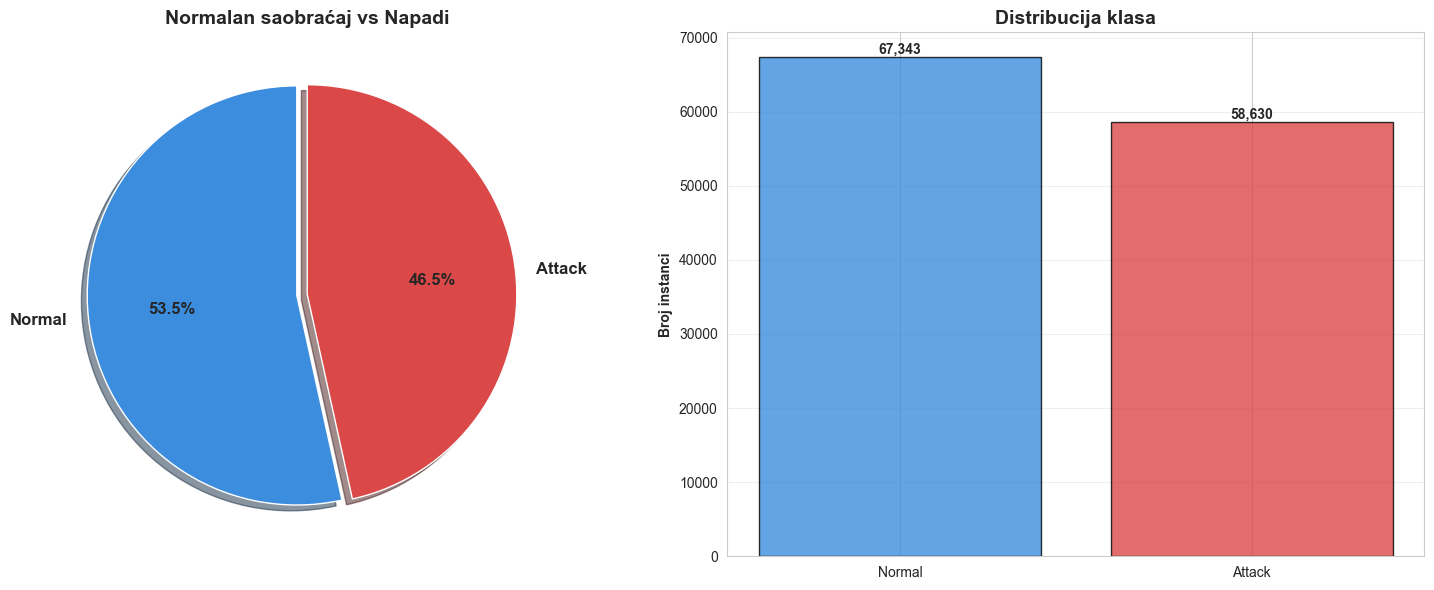

In [152]:
# Vizualizacija distribucije Normal vs Attack
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Izračunavanje brojeva
normal_count = (df['attack_type'] == 'normal').sum()
attack_count = (df['attack_type'] != 'normal').sum()

# Pie chart
labels = ['Normal', 'Attack']
sizes = [normal_count, attack_count]
colors = ["#3C8DDE", "#DB4848"]
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Normalan saobraćaj vs Napadi', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(labels, sizes, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Broj instanci', fontweight='bold')
axes[1].set_title('Distribucija klasa', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(sizes):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Zaključak:** Dataset je približno balansiran između normalnog saobraćaja i napada, što je dobro za treniranje modela - ne moramo koristiti tehnike balansiranja ili prilagođavanje težina.

In [153]:
# Kategorije napada
# Mapiranje pojedinačnih napada u glavne kategorije
attack_categories = {
    'normal': 'Normal',
    'neptune': 'DoS',
    'warezclient': 'R2L',
    'ipsweep': 'Probe',
    'portsweep': 'Probe',
    'teardrop': 'DoS',
    'nmap': 'Probe',
    'satan': 'Probe',
    'smurf': 'DoS',
    'pod': 'DoS',
    'back': 'DoS',
    'guess_passwd': 'R2L',
    'ftp_write': 'R2L',
    'multihop': 'R2L',
    'rootkit': 'U2R',
    'buffer_overflow': 'U2R',
    'imap': 'R2L',
    'warezmaster': 'R2L',
    'phf': 'R2L',
    'land': 'DoS',
    'loadmodule': 'U2R',
    'spy': 'R2L',
    'perl': 'U2R'
}

df['attack_category'] = df['attack_type'].map(attack_categories)

# Distribucija kategorija
category_counts = df['attack_category'].value_counts()
print("\n" + "="*70)
print("DISTRIBUCIJA KATEGORIJA NAPADA")
print("="*70)
print(category_counts)
print(f"\nUkupno kategorija: {df['attack_category'].nunique()}")


DISTRIBUCIJA KATEGORIJA NAPADA
attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Ukupno kategorija: 5


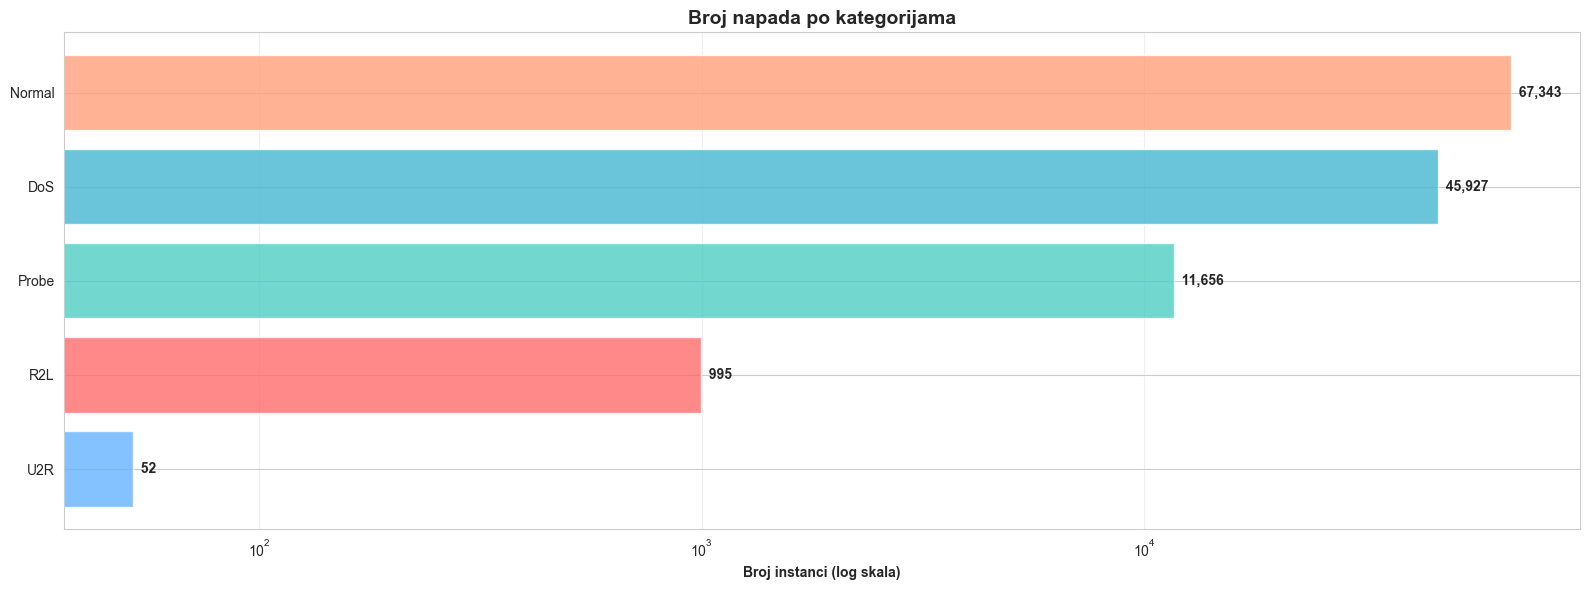

In [154]:
# Vizualizacija kategorija napada
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# Definisanje boja za kategorije napada
colors_cat = ['#66B2FF', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Bar chart sa logaritamskom skalom
category_counts_sorted = category_counts.sort_values(ascending=True)
axes.barh(category_counts_sorted.index, category_counts_sorted.values, color=colors_cat, alpha=0.8)
axes.set_xlabel('Broj instanci (log skala)', fontweight='bold')
axes.set_xscale('log')
axes.set_title('Broj napada po kategorijama', fontsize=14, fontweight='bold')
axes.grid(axis='x', alpha=0.3)

for i, v in enumerate(category_counts_sorted.values):
    axes.text(v, i, f'  {v:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Zaključci o kategorijama napada:**

Ova neravnoteža odražava realnost - DoS napadi su najčešći u praksi, dok su sofisticiraniji napadi (U2R) ređi ali opasniji.

## 4. Analiza kategorijskih obeležja

### Tip protokola

In [155]:
# Identifikacija kategorijskih obeležja
categorical_features = df[FEATURE_NAMES].select_dtypes(include=['object']).columns.tolist()
print(f"Kategorijska obeležja ({len(categorical_features)}):")
print(categorical_features)

Kategorijska obeležja (3):
['duration', 'protocol_type', 'service']


In [156]:
# Analiza protocol_type
protocol_counts = df['protocol_type'].value_counts()
print("\nDistribucija protokola:")
print(protocol_counts)

# Protokol po kategoriji napada
protocol_by_category = pd.crosstab(df['protocol_type'], df['attack_category'])
# Sortiranje po ukupnom broju
protocol_by_category = protocol_by_category.loc[protocol_by_category.sum(axis=1).sort_values(ascending=False).index]

print("\nProtokol po kategoriji napada (sortirano po ukupnom broju):")
print(protocol_by_category)


Distribucija protokola:
protocol_type
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64

Protokol po kategoriji napada (sortirano po ukupnom broju):
attack_category    DoS  Normal  Probe  R2L  U2R
protocol_type                                  
http              2255   38049     30    4    0
private          15971     982   4900    0    0
domain_u             0    9034      9    0    0
smtp               241    7029     43    0    0
ftp_data          1209    4984     51  604   12
...                ...     ...    ...  ...  ...
tftp_u               0       3      0    0    0
http_8001            0       0      2    0    0
harvest              0       0      2    0    0
aol                  0       0      2    0    0
http_2784            0       0      1    0    0

[70 rows x 5 columns]


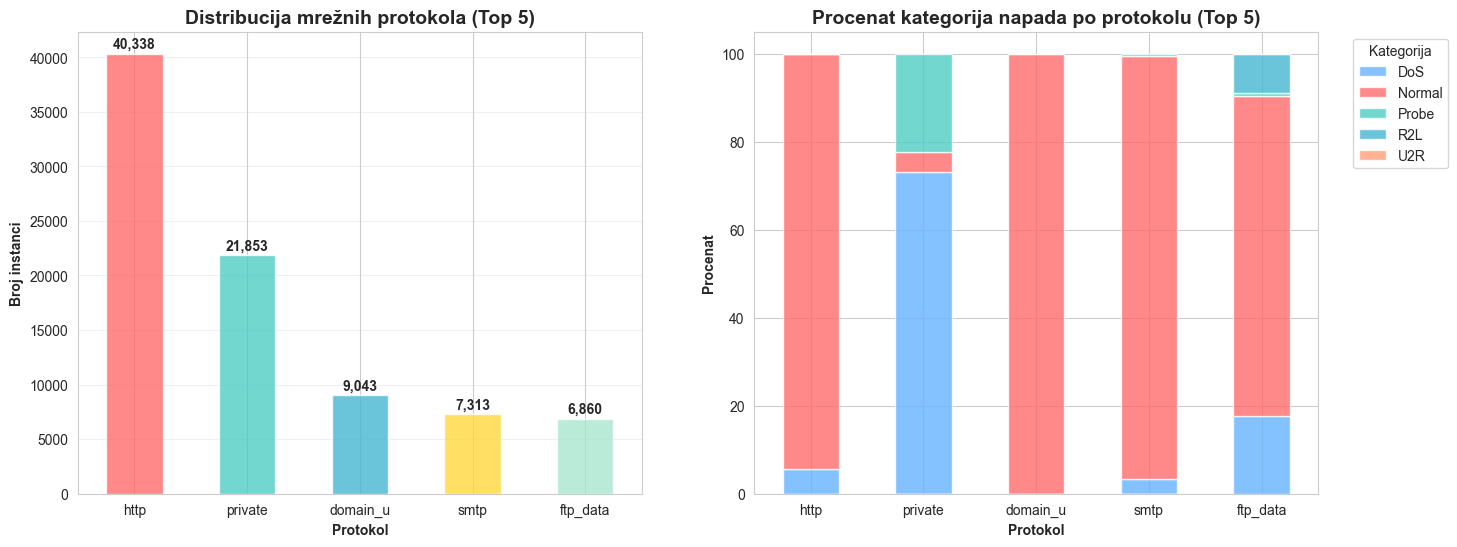

<Figure size 1200x600 with 0 Axes>

In [157]:
# Vizualizacija protocol_type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prvih 5 protokola po ukupnom broju
top_5_protocols = protocol_counts.head(5)

# Ukupna distribucija protokola (top 5)
top_5_protocols.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD93D', '#A8E6CF'][:len(top_5_protocols)], alpha=0.8)
axes[0].set_title('Distribucija mrežnih protokola (Top 5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Protokol', fontweight='bold')
axes[0].set_ylabel('Broj instanci', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(top_5_protocols.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Stacked bar - protokol po kategoriji napada (top 5)
top_5_protocol_names = top_5_protocols.index
protocol_by_category_top5 = protocol_by_category.loc[protocol_by_category.index.isin(top_5_protocol_names)]
protocol_by_category_pct = protocol_by_category_top5.div(protocol_by_category_top5.sum(axis=1), axis=0) * 100
protocol_by_category_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                               color=colors_cat, alpha=0.8)
axes[1].set_title('Procenat kategorija napada po protokolu (Top 5)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Protokol', fontweight='bold')
axes[1].set_ylabel('Procenat', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

axes[1].legend(title='Kategorija', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()


In [158]:
# Analiza service
service_counts = df['service'].value_counts()
print(f"\nUkupno različitih servisa: {df['service'].nunique()}")
print(f"\nTop servisi:")
print(service_counts.head(11))


Ukupno različitih servisa: 11

Top servisi:
service
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


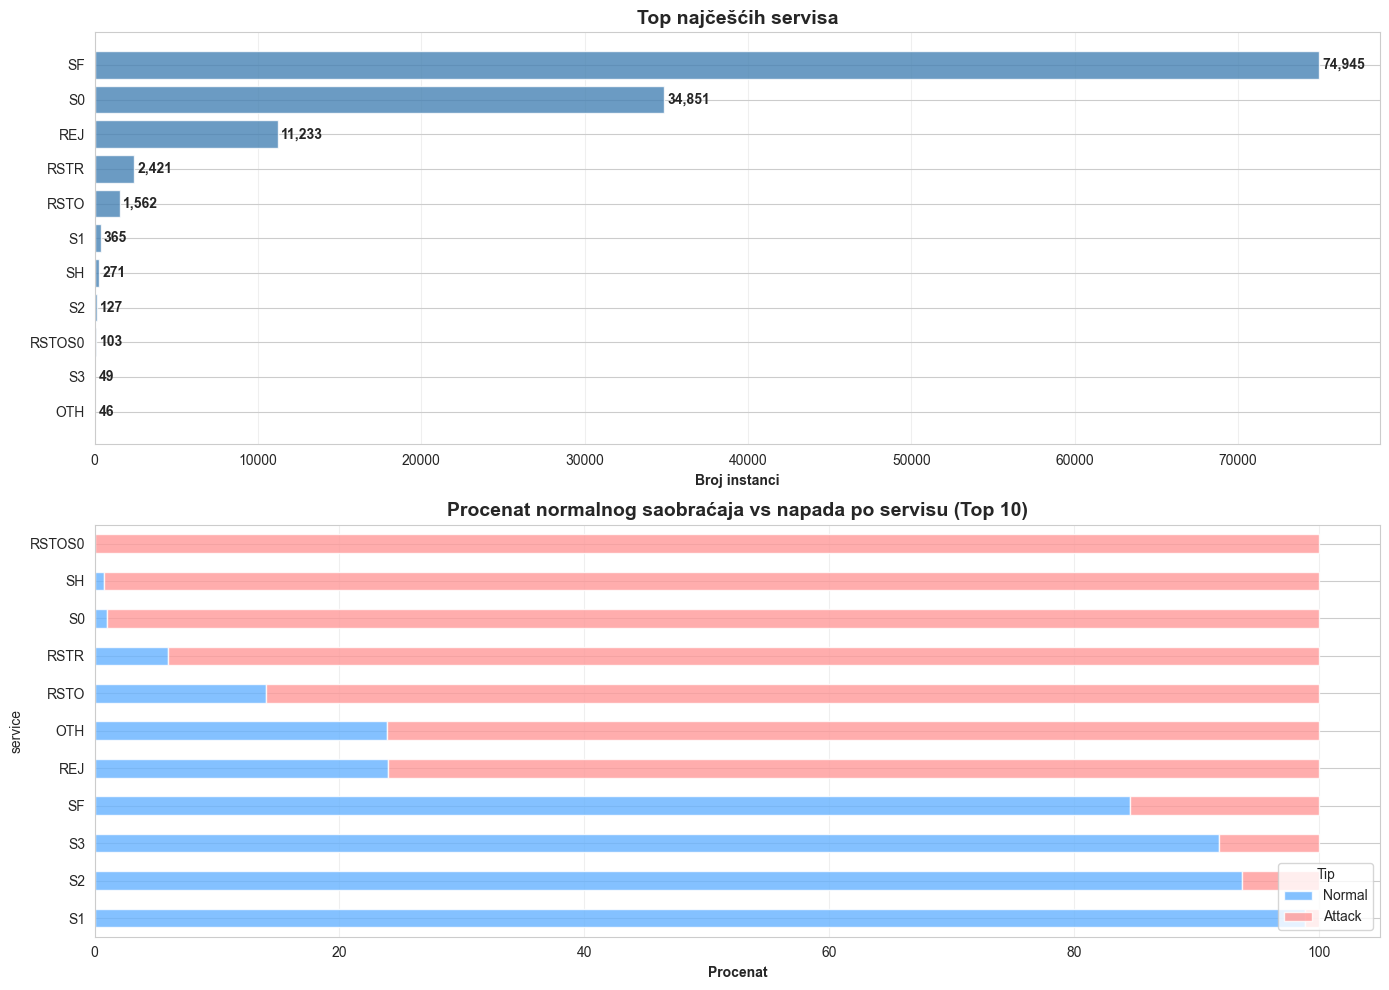

In [159]:
# Vizualizacija top servisa
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Servisi
top_services = service_counts.head(11)
axes[0].barh(range(len(top_services)), top_services.values, color='steelblue', alpha=0.8)
axes[0].set_yticks(range(len(top_services)))
axes[0].set_yticklabels(top_services.index)
axes[0].set_xlabel('Broj instanci', fontweight='bold')
axes[0].set_title('Top najčešćih servisa', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

for i, v in enumerate(top_services.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontweight='bold')

# Distribucija Normal vs Attack
top_10_services = service_counts.head(11).index
df_top_services = df[df['service'].isin(top_10_services)]
service_attack = pd.crosstab(df_top_services['service'], 
                              df_top_services['attack_type'] != 'normal')

service_attack_pct = service_attack.div(service_attack.sum(axis=1), axis=0) * 100
service_attack_pct.columns = ['Normal', 'Attack']
service_attack_pct = service_attack_pct.sort_values('Attack', ascending=True)

service_attack_pct.plot(kind='barh', stacked=True, ax=axes[1], 
                        color=['#66B2FF', '#FF9999'], alpha=0.8)
axes[1].set_xlabel('Procenat', fontweight='bold')
axes[1].set_title('Procenat normalnog saobraćaja vs napada po servisu (Top 10)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(title='Tip', loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Zaključci o servisima:**

1. **RSTOS0** (Originator sent a SYN followed by a RST, no SYN-ACK from the responder) - servis ima najveću koncentraciju napada
2. **S1** ima nizak procenat napada - normalan transfer podataka
3. **SF (Normal establishment and termination)** je najčešći - normalno zatvaranje konekcije, ima više normalnog saobraćaja u odnosu na napad
4. **S0 (Connection attempt seen, no reply)** je **jak indikator napada** - ovo je tipično za port scanning i DoS napade
5. **REJ (Connection rejected)** takođe pokazuje visok procenat napada


### Analiza flag obeležja

In [160]:
# Analiza flag obeležja
flag_counts = df['flag'].value_counts()
print(f"\nUkupno različitih flag vrednosti: {df['flag'].nunique()}")
print(f"\nDistribucija flag-ova:")
print(flag_counts)

# Flag po kategoriji napada
flag_by_category = pd.crosstab(df['flag'], df['attack_category'])
print("\nFlag po kategoriji napada:")
print(flag_by_category)


Ukupno različitih flag vrednosti: 3341

Distribucija flag-ova:
flag
0        49392
8         3691
1         2432
44        2334
45        2089
         ...  
1940         1
12973        1
1899         1
1661         1
2358         1
Name: count, Length: 3341, dtype: int64

Flag po kategoriji napada:
attack_category    DoS  Normal  Probe  R2L  U2R
flag                                           
0                41231    3415   4704   30   12
1                    0       8   2424    0    0
4                    0       0      0    0    2
5                    0      12     16    0    0
6                    0      68     79    0    0
...                ...     ...    ...  ...  ...
381709090            0       0      1    0    0
621568663            0       0      1    0    0
693375640            0       0      1    0    0
1167519497           0       0      1    0    0
1379963888           0       0      1    0    0

[3341 rows x 5 columns]


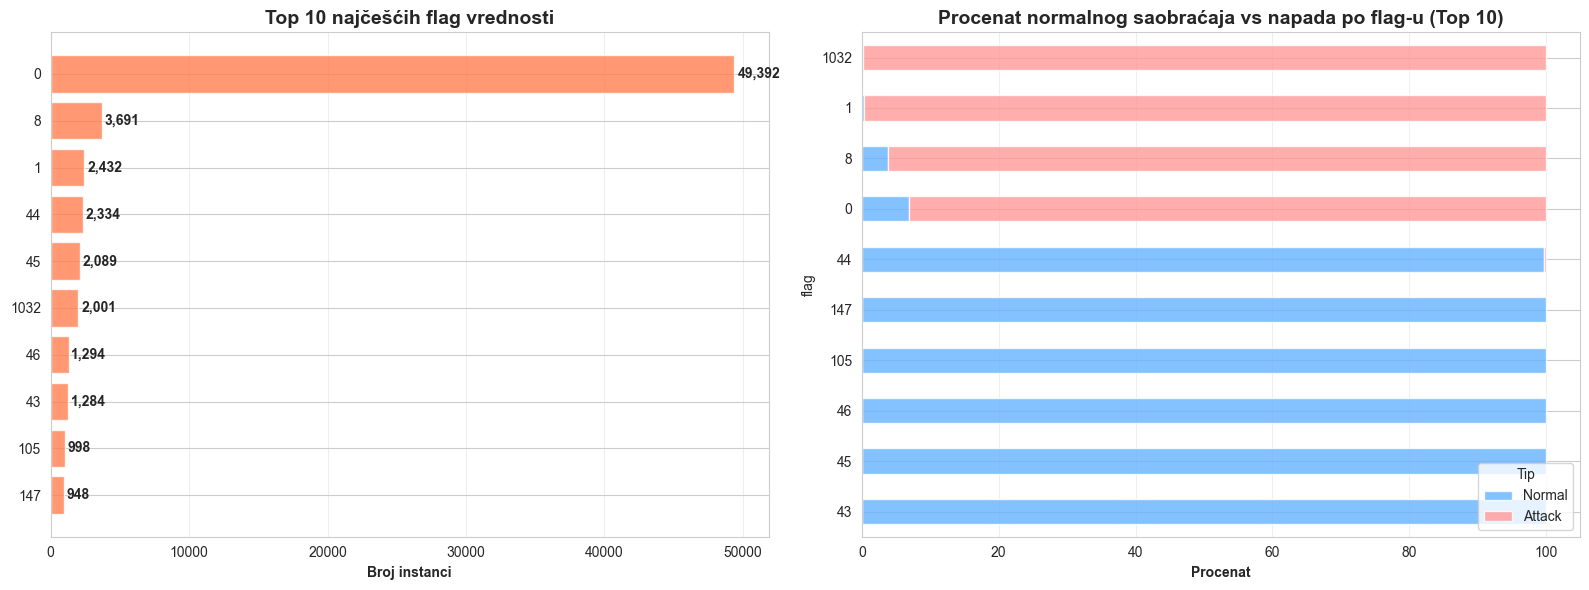

In [161]:
# Vizualizacija flag distribucije
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ukupna distribucija flagova
top_flags = flag_counts.head(10)
axes[0].barh(range(len(top_flags)), top_flags.values, color='coral', alpha=0.8)
axes[0].set_yticks(range(len(top_flags)))
axes[0].set_yticklabels(top_flags.index)
axes[0].set_xlabel('Broj instanci', fontweight='bold')
axes[0].set_title('Top 10 najčešćih flag vrednosti', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

for i, v in enumerate(top_flags.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontweight='bold')

# Procenat napada po flagu
top_10_flags = flag_counts.head(10).index
df_top_flags = df[df['flag'].isin(top_10_flags)]
flag_attack = pd.crosstab(df_top_flags['flag'], 
                          df_top_flags['attack_type'] != 'normal')

flag_attack_pct = flag_attack.div(flag_attack.sum(axis=1), axis=0) * 100
flag_attack_pct.columns = ['Normal', 'Attack']
flag_attack_pct = flag_attack_pct.sort_values('Attack', ascending=True)

flag_attack_pct.plot(kind='barh', stacked=True, ax=axes[1], 
                     color=['#66B2FF', '#FF9999'], alpha=0.8)
axes[1].set_xlabel('Procenat', fontweight='bold')
axes[1].set_title('Procenat normalnog saobraćaja vs napada po flag-u (Top 10)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(title='Tip', loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analiza numeričkih obeležja

In [162]:
# Identifikacija numeričkih obeležja
numerical_features = df[FEATURE_NAMES].select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerička obeležja ({len(numerical_features)}):")
print(numerical_features)

Numerička obeležja (37):
['flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [163]:
# Osnovna statistika numeričkih obeležja
df[numerical_features].describe()

,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


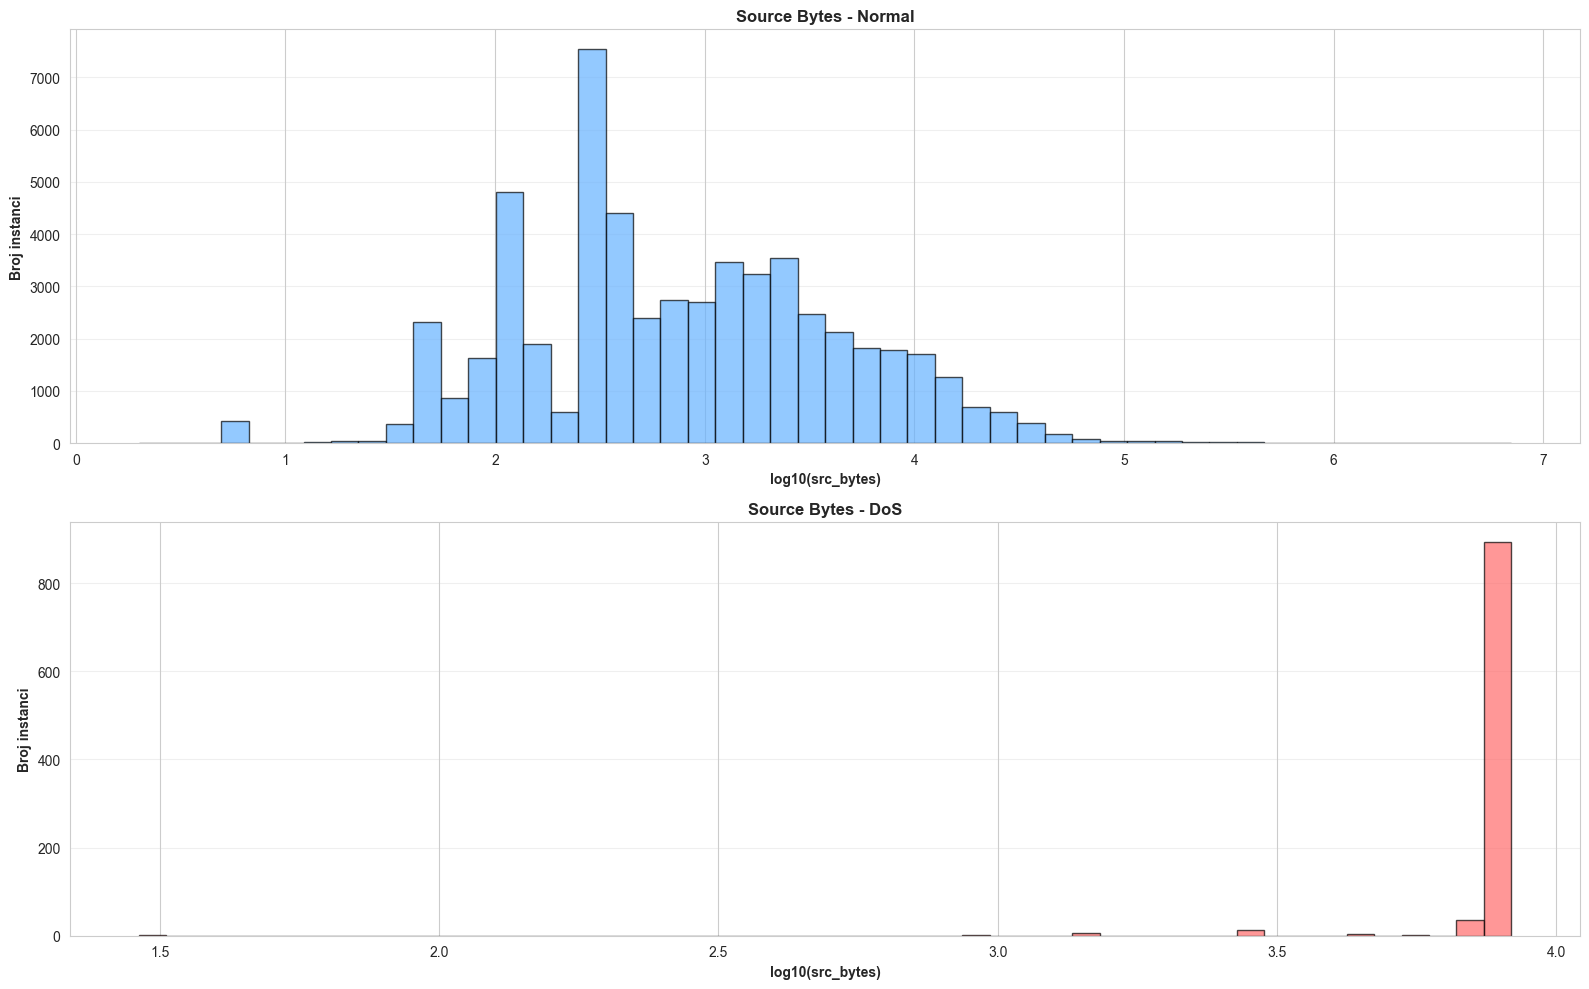

In [164]:
# Analiza src_bytes i dst_bytes
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Definisanje boja za kategorije
colors_cat = ['#66B2FF', '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Uzimamo prvih nekoliko kategorija
categories = list(df['attack_category'].unique()[:2])

# src_bytes po kategoriji
for i, category in enumerate(categories):
    subset = df[df['attack_category'] == category]['src_bytes']
    subset_filtered = subset[subset > 0]  # Ukloni 0 vrednosti za log skalu
    if len(subset_filtered) > 0:
        axes[i].hist(np.log10(subset_filtered + 1), bins=50, color=colors_cat[i], alpha=0.7, edgecolor='black')
    axes[i].set_xlabel('log10(src_bytes)', fontweight='bold')
    axes[i].set_ylabel('Broj instanci', fontweight='bold')
    axes[i].set_title(f'Source Bytes - {category}', fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

**Zaključak o src_bytes:** Normalan saobraćaj ima raznovrsniju distribuciju byte-ova, dok napadi (posebno DoS) često imaju karakteristične (visoke) vrednosti.

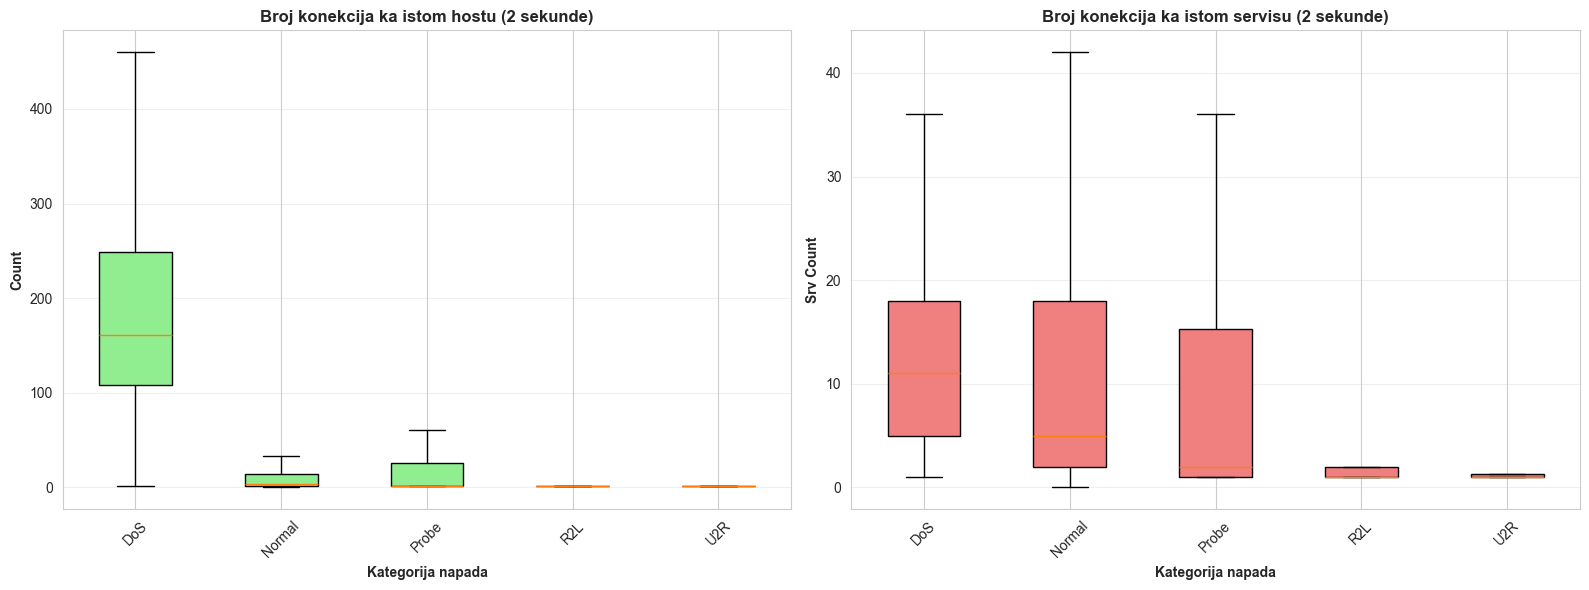

In [165]:
# Analiza count i srv_count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# count - broj konekcija ka istom hostu
df_sample = df.sample(n=min(10000, len(df)), random_state=42)
box_data_count = [df_sample[df_sample['attack_category'] == cat]['count'].values 
                  for cat in sorted(df_sample['attack_category'].unique())]

bp1 = axes[0].boxplot(box_data_count, labels=sorted(df_sample['attack_category'].unique()),
                      showfliers=False, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('lightgreen')
    
axes[0].set_xlabel('Kategorija napada', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Broj konekcija ka istom hostu (2 sekunde)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# srv_count - broj konekcija ka istom servisu
box_data_srv = [df_sample[df_sample['attack_category'] == cat]['srv_count'].values 
                for cat in sorted(df_sample['attack_category'].unique())]

bp2 = axes[1].boxplot(box_data_srv, labels=sorted(df_sample['attack_category'].unique()),
                      showfliers=False, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightcoral')
    
axes[1].set_xlabel('Kategorija napada', fontweight='bold')
axes[1].set_ylabel('Srv Count', fontweight='bold')
axes[1].set_title('Broj konekcija ka istom servisu (2 sekunde)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Zaključak o count i srv_count:** 
- **DoS napadi** imaju veoma visoke vrednosti count- šalju mnogo konekcija u kratkom periodu
- **Probe napadi** imaju slične vrednosti normalnom saobraćaju

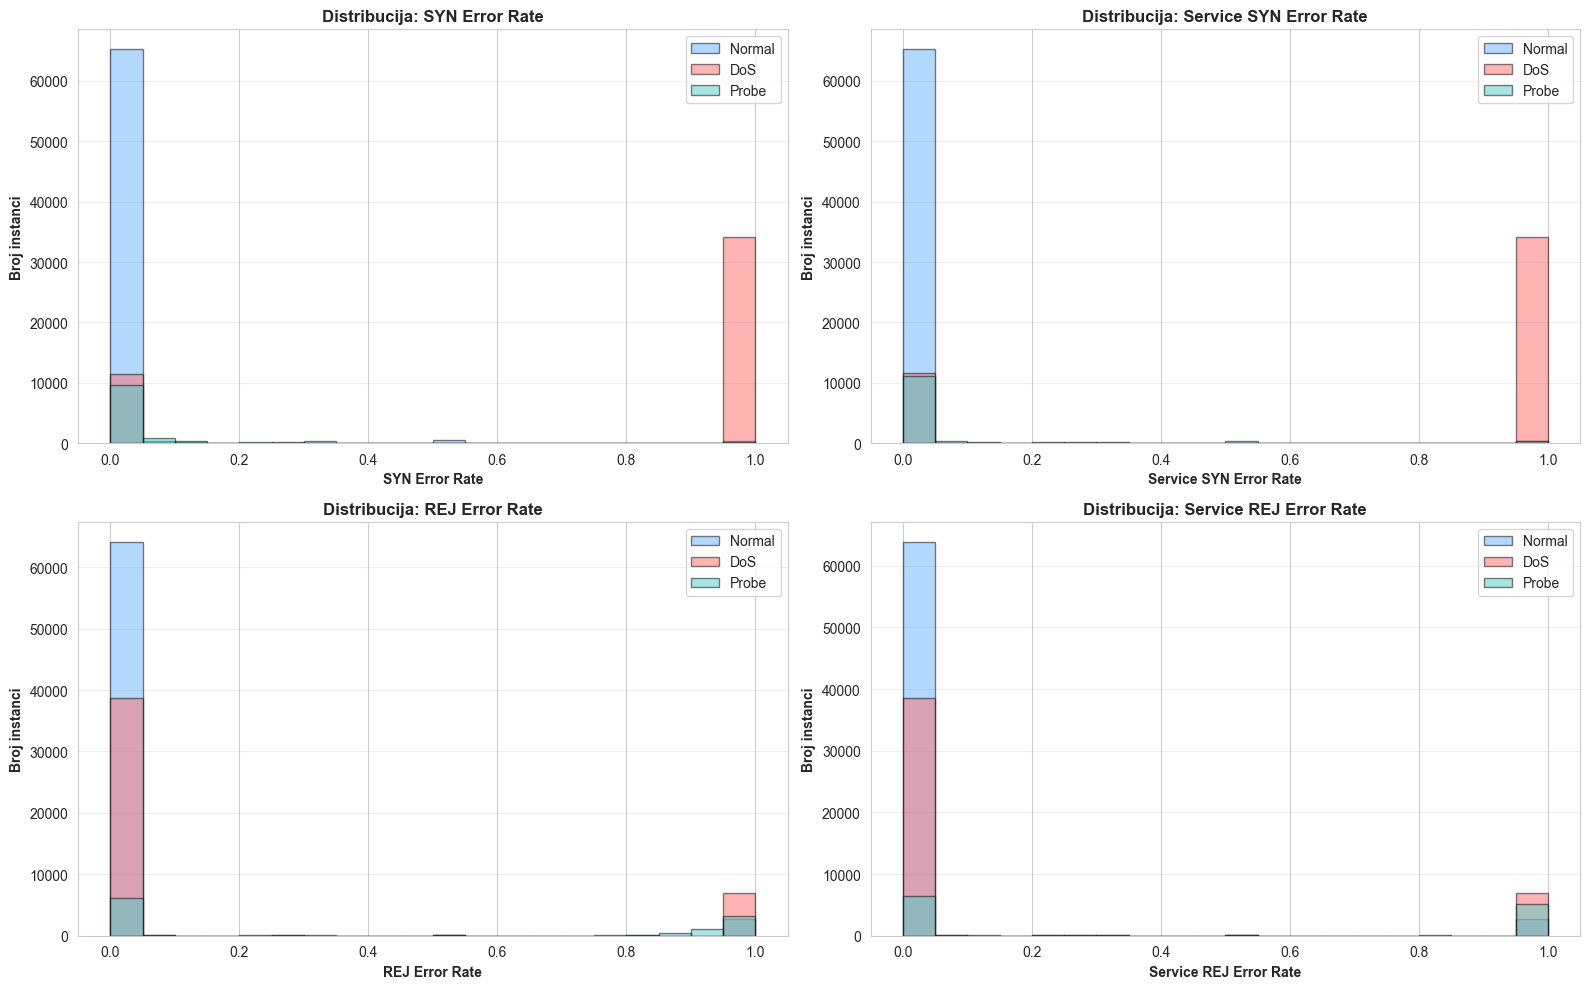

In [166]:
# Analiza rate obeležja - serror_rate, rerror_rate
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

rate_features = ['serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate']
titles = ['SYN Error Rate', 'Service SYN Error Rate', 'REJ Error Rate', 'Service REJ Error Rate']
colors_hist = ['#66B2FF', '#FF6B6B', '#4ECDC4']

for idx, (feature, title) in enumerate(zip(rate_features, titles)):
    row = idx // 2
    col = idx % 2
    
    # Distribucija po kategoriji napada
    categories_to_plot = ['Normal', 'DoS', 'Probe']
    for cat_idx, category in enumerate(categories_to_plot):
        if category in df['attack_category'].unique():
            subset = df[df['attack_category'] == category][feature]
            axes[row, col].hist(subset, bins=20, alpha=0.5, label=category, 
                              color=colors_hist[cat_idx], edgecolor='black')
    
    axes[row, col].set_xlabel(title, fontweight='bold')
    axes[row, col].set_ylabel('Broj instanci', fontweight='bold')
    axes[row, col].set_title(f'Distribucija: {title}', fontsize=12, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Zaključak o error rate obeležjima:**
- **serror_rate** (SYN errors) je **ekstremno visok kod DoS napada** - napadi često koriste SYN flooding
- **Normal** saobraćaj ima nizak error rate
- Error rate obeležja su **veoma diskriminativna** za detekciju napada

## 6. Korelacija između obeležja

In [167]:
# Izračunavanje korelacione matrice za numerička obeležja (sample radi brzine)
# Osiguramo da koristimo samo numeričke kolone
numerical_cols = df[FEATURE_NAMES].select_dtypes(include=['int64', 'float64']).columns.tolist()
df_sample = df[numerical_cols].sample(n=5000, random_state=42)
correlation_matrix = df_sample.corr()

# Top korelirane parove
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]  # Ukloni dijagonalu
top_corr = corr_pairs.abs().sort_values(ascending=False).head(20)

print("="*70)
print("TOP 20 KORELIRANIH PAROVA OBELEŽJA")
print("="*70)
for (feat1, feat2), corr in top_corr.items():
    print(f"{feat1:30s} <-> {feat2:30s} : {corr:.3f}")

TOP 20 KORELIRANIH PAROVA OBELEŽJA
num_root                       <-> num_compromised                : 0.999
num_compromised                <-> num_root                       : 0.999
srv_serror_rate                <-> serror_rate                    : 0.991
serror_rate                    <-> srv_serror_rate                : 0.991
srv_serror_rate                <-> dst_host_srv_serror_rate       : 0.986
dst_host_srv_serror_rate       <-> srv_serror_rate                : 0.986
srv_rerror_rate                <-> rerror_rate                    : 0.984
rerror_rate                    <-> srv_rerror_rate                : 0.984
dst_host_serror_rate           <-> dst_host_srv_serror_rate       : 0.982
dst_host_srv_serror_rate       <-> dst_host_serror_rate           : 0.982
serror_rate                    <-> dst_host_srv_serror_rate       : 0.979
dst_host_srv_serror_rate       <-> serror_rate                    : 0.979
dst_host_serror_rate           <-> serror_rate                    : 0.979
ser

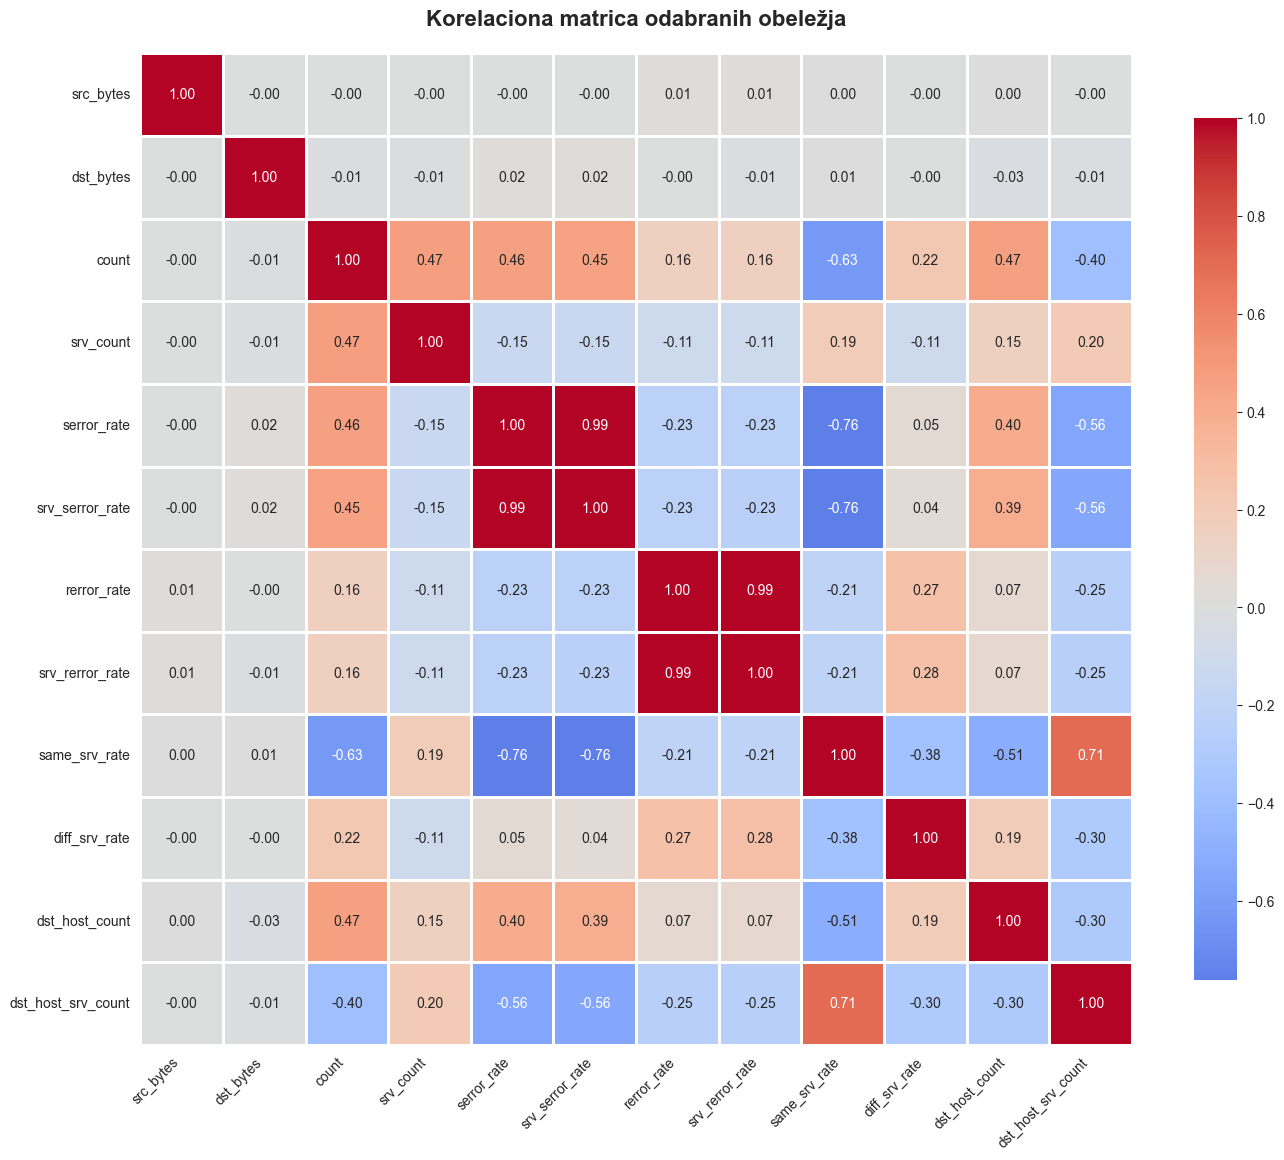

In [168]:
# Heatmap korelacije za odabrana obeležja
selected_features = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count'
]

# Osiguramo da su sve kolone numeričke
selected_numeric = [col for col in selected_features if col in df.select_dtypes(include=['int64', 'float64']).columns]
corr_selected = df[selected_numeric].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_selected, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Korelaciona matrica odabranih obeležja', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()